In [1]:
import pandas as pd

In [4]:
churne= pd.read_csv (r"C:\Users\USER\Downloads\churne.csv")

In [6]:
churne.head(20)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
5,AL,118,510,Yes,No,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False
6,MA,121,510,No,Yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,False
7,MO,147,415,Yes,No,0,157.0,79,26.69,103.1,94,8.76,211.8,96,9.53,7.1,6,1.92,0,False
8,WV,141,415,Yes,Yes,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,False
9,RI,74,415,No,No,0,187.7,127,31.91,163.4,148,13.89,196.0,94,8.82,9.1,5,2.46,0,False


In [8]:
# We use double brackets for X because it expects a 2D array (even for one column)
X = churne[['Total day minutes']] 
y = churne['Total day charge']

In [9]:
from sklearn.model_selection import train_test_split

# We usually save 20% of the data for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 2132
Testing samples: 534


In [10]:
from sklearn.linear_model import LinearRegression

# Create the model object
model = LinearRegression()

# Train the model (This is where the 'learning' happens)
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions
predictions = model.predict(X_test)

# Check accuracy
print(f"R-squared Score: {r2_score(y_test, predictions)}")

R-squared Score: 0.9999999018196307


In [12]:
# The slope (m) tells us the cost per minute
print(f"Cost per minute (Coefficient): {model.coef_[0]}")

# The intercept (b) tells us the starting cost even if 0 minutes are used
print(f"Base charge (Intercept): {model.intercept_}")

Cost per minute (Coefficient): 0.16999990769756987
Base charge (Intercept): 0.0005663574898626678


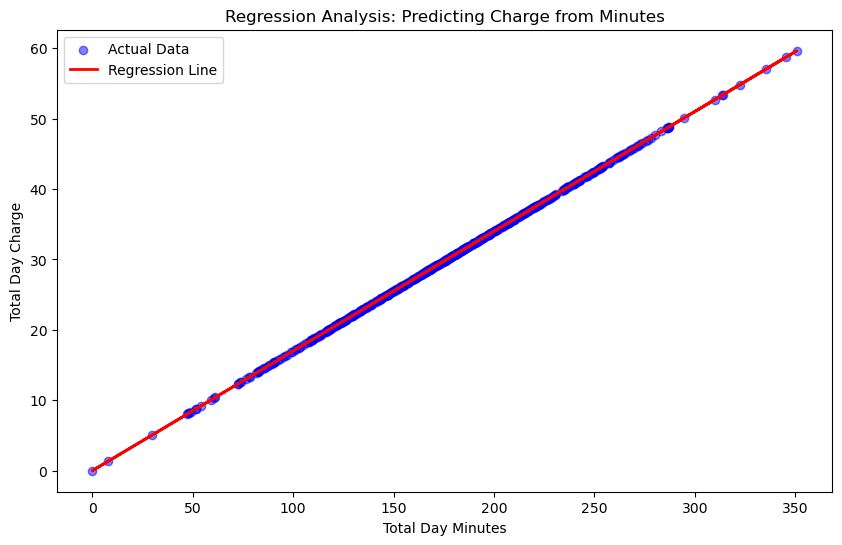

In [14]:
import matplotlib.pyplot as plt

# 1. Create the plot area
plt.figure(figsize=(10, 6))

# 2. Plot the real data points from your test set
plt.scatter(X_test, y_test, color='blue', label='Actual Data', alpha=0.5)

# 3. Plot the straight line the model "thinks" is the truth
plt.plot(X_test, predictions, color='red', linewidth=2, label='Regression Line')

# 4. Add labels so it looks professional
plt.xlabel('Total Day Minutes')
plt.ylabel('Total Day Charge')
plt.title('Regression Analysis: Predicting Charge from Minutes')
plt.legend()

# 5. Show the result
plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Pick features that define behavior
features = ['Total day minutes', 'Total day charge', 'Customer service calls']
data_for_clustering = churne[features]

# 2. Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_clustering)

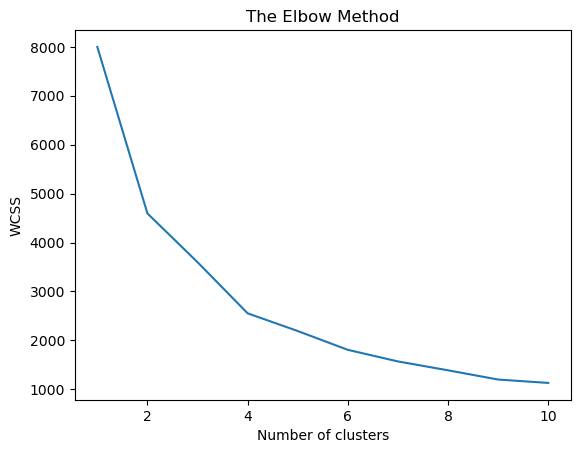

In [17]:
wcss = [] # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
    
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [20]:
# 3. Apply K-Means
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
churne['Customer_Segment'] = kmeans.fit_transform(scaled_data).argmax(axis=1)

# 4. See the averages for each segment
churne.groupby('Customer_Segment')[features].mean()

,Total day minutes,Total day charge,Customer service calls
Customer_Segment,,,
0,169.819588,28.870206,4.855670
1,135.646495,23.060491,1.390187
2,224.011984,38.082482,1.486381
